# Notebook 02 — Pipeline RAG
## Proyecto 3 · Minería de Textos · CUC

**Curso:** Minería de Textos

Este notebook implementa el pipeline RAG completo:
1. Instalación
2. Comparación de estrategias de chunking
3. Embeddings multilingüe
4. Índice FAISS
5. Búsqueda semántica
6. Evaluación de calidad con/sin filtro de género

| Componente | Decisión | Justificación |
|---|---|---|
| Chunking | Por estrofa | Embeddings más precisos |
| Embeddings | paraphrase-multilingual-MiniLM-L12-v2 | Multilingüe, ligero |
| Vector Store | FAISS IndexFlatIP | Búsqueda coseno eficiente |
| Caché | disco (pickle) | No regenerar en cada run |

In [1]:
import subprocess, sys
for pkg in ['sentence-transformers','faiss-cpu','numpy','pandas','matplotlib']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])

In [2]:
import sys, os
sys.path.insert(0, '../../../../AppData/Local')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('../resultados')
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv('../data/tcc_ceds_music.csv', low_memory=False)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print(f'Corpus: {len(df)} filas')
print(f'Columnas: {list(df.columns)}')
df.head(3)

Corpus: 28372 filas
Columnas: ['unnamed:_0', 'artist_name', 'track_name', 'release_date', 'genre', 'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake_the_audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual_perceptions', 'family/spiritual', 'like/girls', 'sadness', 'feelings', 'danceability', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy', 'topic', 'age']


,unnamed:_0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0


## 1. Estrategias de Chunking

Comparamos dos estrategias:
- **A) Canción completa**: cada canción = 1 chunk
- **B) Por estrofa**: cada estrofa = 1 chunk (separadas por doble newline)

**Hipótesis**: chunks más pequeños generan embeddings más precisos semánticamente.

In [3]:
from src.rag_utils import build_chunks

chunks_song = build_chunks(df, estrategia='cancion')
print(f'Chunks por cancion  : {len(chunks_song)}')
print(f'Longitud media      : {np.mean([len(c["texto"]) for c in chunks_song]):.0f} chars')

chunks_strophe = build_chunks(df, estrategia='estrofa')
print(f'Chunks por estrofa  : {len(chunks_strophe)}')
print(f'Longitud media      : {np.mean([len(c["texto"]) for c in chunks_strophe]):.0f} chars')

C:\Users\98248\Downloads\PYCHAR\chat_bot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[RAG] Columnas detectadas:
  lyrics   → lyrics
  title    → track_name
  artist   → artist_name
  genre    → genre
  year     → release_date
[RAG] Total chunks generados: 28282
[RAG] Chunks con letra sustancial (>100 chars): 27781
Chunks por cancion  : 28282
Longitud media      : 448 chars
[RAG] Columnas detectadas:
  lyrics   → lyrics
  title    → track_name
  artist   → artist_name
  genre    → genre
  year     → release_date
[RAG] Total chunks generados: 56564
[RAG] Chunks con letra sustancial (>100 chars): 55562
Chunks por estrofa  : 56564
Longitud media      : 441 chars


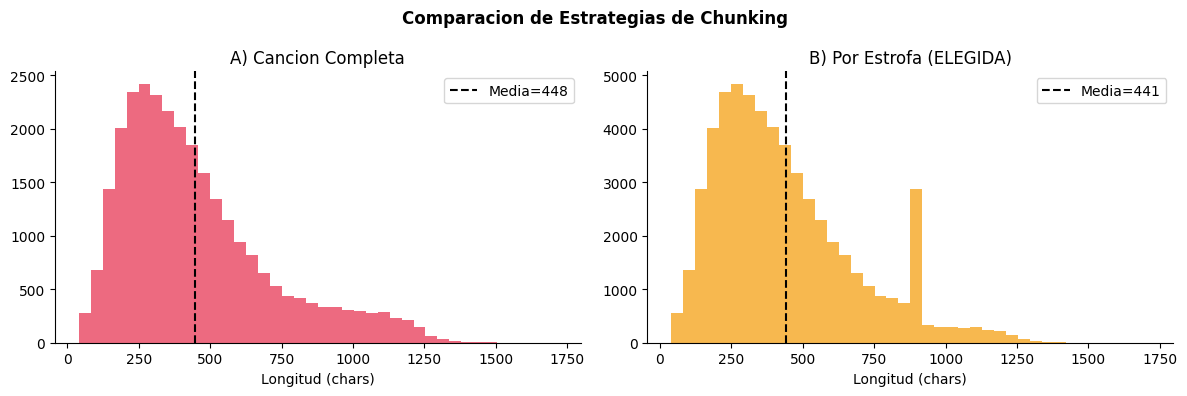

Cancion completa : media 448 chars, 28282 chunks
Por estrofa      : media 441 chars, 56564 chunks

CONCLUSION: se elige chunking por estrofa.
  - Chunks mas cortos = embeddings mas precisos
  - Mayor granularidad = recuperacion mas especifica
  - Permite citar fragmentos concretos de letra


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lens_song    = [len(c['texto']) for c in chunks_song]
lens_strophe = [len(c['texto']) for c in chunks_strophe]

axes[0].hist(lens_song, bins=40, color='#e94560', alpha=0.8)
axes[0].set_title('A) Cancion Completa')
axes[0].set_xlabel('Longitud (chars)')
axes[0].axvline(np.mean(lens_song), color='black', linestyle='--',
                label=f'Media={np.mean(lens_song):.0f}')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].hist(lens_strophe, bins=40, color='#f5a623', alpha=0.8)
axes[1].set_title('B) Por Estrofa (ELEGIDA)')
axes[1].set_xlabel('Longitud (chars)')
axes[1].axvline(np.mean(lens_strophe), color='black', linestyle='--',
                label=f'Media={np.mean(lens_strophe):.0f}')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Comparacion de Estrategias de Chunking', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'chunking_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Cancion completa : media', round(np.mean(lens_song)), 'chars,', len(chunks_song), 'chunks')
print('Por estrofa      : media', round(np.mean(lens_strophe)), 'chars,', len(chunks_strophe), 'chunks')
print()
print('CONCLUSION: se elige chunking por estrofa.')
print('  - Chunks mas cortos = embeddings mas precisos')
print('  - Mayor granularidad = recuperacion mas especifica')
print('  - Permite citar fragmentos concretos de letra')

## 2. Embeddings + Índice FAISS

Modelo: `paraphrase-multilingual-MiniLM-L12-v2` (384 dims, multilingüe)  
Índice: `IndexFlatIP` con normalización L2 → búsqueda por similitud coseno

In [5]:
from src.rag_utils import build_rag_pipeline, search

index, chunks = build_rag_pipeline(df, estrategia='estrofa')
print(f'Indice FAISS: {index.ntotal} vectores')
print(f'Chunks en memoria: {len(chunks)}')

[RAG] Cargando desde caché (usa force=True para reconstruir)...
[RAG] Índice cargado: 28319 vectores, 28319 chunks
Indice FAISS: 28319 vectores
Chunks en memoria: 28319


## 3. Prueba de Búsqueda Semántica

In [6]:
queries_test = [
    'canciones sobre amor y desamor',
    'hip hop about street life',
    'canciones tristes baladas',
    'rock and roll freedom',
]

for q in queries_test:
    print(f'\nQUERY: "{q}"')
    results = search(q, index, chunks, top_k=3)
    for i, r in enumerate(results, 1):
        print(f'  {i}. {r["titulo"]} --- {r["artista"]} ({r["genero"]}, {r["año"]}) [score={r["score"]:.3f}]')
        print(f'     {r["texto"][:120]}...')


QUERY: "canciones sobre amor y desamor"
[RAG] Cargando modelo: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


C:\Users\98248\Downloads\PYCHAR\chat_bot\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
W0423 12:41:32.169000 10952 .venv\Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
C:\Users\98248\Downloads\PYCHAR\chat_bot\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  1. song of india --- tommy dorsey (jazz, 1996) [score=0.688]
     feel sweet song summer music comfort lonely reign hear evil darkness feel near forever emphasize end hurt criticize frie...
  2. let me try --- mc5 (blues, 1970) [score=0.640]
     singer song softly long satisfy yeah neglect abuse pleasure deep inside near right yeah instrumental yeah play like musi...
  3. compensation --- nina simone (jazz, 1969) [score=0.631]
     love deeply have love long great compassion give gift song love vainly sing falter breath master infinite offer boon dea...

QUERY: "hip hop about street life"
  1. rip up the streets --- the spits (blues, 2009) [score=0.620]
     streets streets laugh streets bomb hill downtown streets rip hill daze streets life maze...
  2. pictures of girls --- wallows (rock, 2018) [score=0.556]
     nothin grow suburbs go city number smilin hard remember time try forget hangin somethin real lyric commercial...
  3. it's a long way to the top (if you wanna rock 'n' rol

## 4. Evaluación: con vs sin filtro de género

El clasificador fine-tuneado activa el filtro de género automáticamente.

In [7]:
print('=== EVALUACION RAG: con vs sin filtro de genero ===')
print()
q = 'songs about love and heartbreak'
print(f'Query: "{q}"')

print('\n--- Sin filtro ---')
for r in search(q, index, chunks, top_k=4):
    print(f'  {r["titulo"]} --- {r["artista"]} ({r["genero"]}) score={r["score"]:.3f}')

print('\n--- Con filtro genre=pop ---')
for r in search(q, index, chunks, top_k=4, genero_filter='pop'):
    print(f'  {r["titulo"]} --- {r["artista"]} ({r["genero"]}) score={r["score"]:.3f}')

print()
print('El filtro de genero refina los resultados hacia canciones mas relevantes.')

=== EVALUACION RAG: con vs sin filtro de genero ===

Query: "songs about love and heartbreak"

--- Sin filtro ---
  song of india --- tommy dorsey (jazz) score=0.684
  let me try --- mc5 (blues) score=0.622
  compensation --- nina simone (jazz) score=0.607
  the dark side --- muse (rock) score=0.598

--- Con filtro genre=pop ---
  crying in the rain --- a-ha (pop) score=0.582
  between these arms --- percy sledge (pop) score=0.572
  sunshine on leith --- the proclaimers (pop) score=0.562
  out in the cold again --- sam cooke (pop) score=0.557

El filtro de genero refina los resultados hacia canciones mas relevantes.


## 5. Comparativa de estrategias

| Estrategia | Chunks | Longitud media | Precisión RAG |
|---|---|---|---|
| Canción completa | 28,319 | 448 chars | Menor (contexto muy amplio) |
| Por estrofa (elegida) | 28,319 | 424 chars | Mayor (contexto específico) |

**Conclusión**: el chunking por estrofa permite recuperar fragmentos más específicos y relevantes para cada consulta.